In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

In [3]:
print([x for x in globals() if not x.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'nx', 'plt', 'Path', 'tqdm']


In [6]:
from pathlib import Path

processed_path = Path("../data/processed")

print("Processed directory:")
print(processed_path.resolve())

print("\nFiles:")
for file in processed_path.iterdir():
    print(file.name)

Processed directory:
C:\Users\ADMIN\FinGraph-Sentinel\data\processed

Files:
community_analysis.csv
company_risk_scores.csv
correlation_matrix.csv
financial_graph.gml
graph_metrics.csv
stock_prices_clean.csv


In [7]:
import pandas as pd
import networkx as nx
from pathlib import Path

processed_path = Path("../data/processed")

stock_prices = pd.read_csv(
    processed_path / "stock_prices_clean.csv"
)

print("Shape:", stock_prices.shape)
print("\nColumns:")
print(stock_prices.columns.tolist())

print("\nFirst 5 rows:")
display(stock_prices.head())

Shape: (12550, 10)

Columns:
['date', 'open', 'high', 'low', 'close', 'volume', 'dividends', 'stock splits', 'ticker', 'company']

First 5 rows:


,date,open,high,low,close,volume,dividends,stock splits,ticker,company
0,2021-08-19 04:00:00,141.458092,144.354945,140.941146,143.086960,86960300,0.0,0.0,AAPL,Apple
1,2021-08-20 04:00:00,143.808694,144.842585,143.164946,144.540222,60549600,0.0,0.0,AAPL,Apple
2,2021-08-23 04:00:00,144.657268,146.490971,144.247614,146.022797,60131800,0.0,0.0,AAPL,Apple
3,2021-08-24 04:00:00,145.769202,147.144478,145.476587,145.935013,48606400,0.0,0.0,AAPL,Apple
4,2021-08-25 04:00:00,146.120355,146.617804,144.159864,144.706070,58991300,0.0,0.0,AAPL,Apple


In [8]:
print(stock_prices.info())

<class 'pandas.DataFrame'>
RangeIndex: 12550 entries, 0 to 12549
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          12550 non-null  str    
 1   open          12550 non-null  float64
 2   high          12550 non-null  float64
 3   low           12550 non-null  float64
 4   close         12550 non-null  float64
 5   volume        12550 non-null  int64  
 6   dividends     12550 non-null  float64
 7   stock splits  12550 non-null  float64
 8   ticker        12550 non-null  str    
 9   company       12550 non-null  str    
dtypes: float64(6), int64(1), str(3)
memory usage: 980.6 KB
None


In [9]:
prices_df = stock_prices.pivot(
    index="date",
    columns="ticker",
    values="close"
)

returns_df = prices_df.pct_change().dropna()

print("Returns shape:", returns_df.shape)

Returns shape: (1254, 10)


In [11]:
import networkx as nx

# 1. Calculate correlation matrix
corr_matrix = returns_df.corr()

# 2. Create graph
G = nx.Graph()

# 3. Add all companies as nodes
for company in corr_matrix.columns:
    G.add_node(company)

# 4. Add edges for sufficiently strong correlations
threshold = 0.5

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        company_a = corr_matrix.columns[i]
        company_b = corr_matrix.columns[j]

        correlation = corr_matrix.iloc[i, j]

        if abs(correlation) >= threshold:
            G.add_edge(
                company_a,
                company_b,
                correlation=correlation,
                weight=abs(correlation)
            )

print("Graph successfully created!")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Graph successfully created!
Nodes: 10
Edges: 12


In [12]:
print("Returns shape:", returns_df.shape)
print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

Returns shape: (1254, 10)
Graph nodes: 10
Graph edges: 12


In [13]:
returns_df.head()

ticker,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
date,,,,,,,,,,
2021-08-20 04:00:00,0.010156,0.003827,0.012894,0.002852,-0.006493,0.011968,0.025576,0.051419,0.010082,-0.000907
2021-08-23 04:00:00,0.010257,0.020600,0.019006,0.012797,0.016958,0.011075,0.000952,0.054862,0.038280,0.012016
2021-08-24 04:00:00,-0.000601,0.012220,0.008712,0.006190,0.002133,0.005945,-0.006663,-0.007514,0.003101,0.000427
2021-08-25 04:00:00,-0.008421,-0.001997,0.005787,0.020613,-0.007407,0.007879,-0.002016,0.019272,0.003825,-0.007044
2021-08-26 04:00:00,-0.005528,0.005098,-0.004494,0.005158,-0.017377,-0.010885,-0.009669,-0.006528,-0.014117,-0.008900


In [14]:
G.nodes(data=True)

NodeDataView({'AAPL': {}, 'AMZN': {}, 'GOOGL': {}, 'JPM': {}, 'MA': {}, 'META': {}, 'MSFT': {}, 'NVDA': {}, 'TSLA': {}, 'V': {}})

In [15]:
G.edges(data=True)

EdgeDataView([('AAPL', 'GOOGL', {'correlation': np.float64(0.5173315550192197), 'weight': np.float64(0.5173315550192197)}), ('AAPL', 'MSFT', {'correlation': np.float64(0.5315617447826457), 'weight': np.float64(0.5315617447826457)}), ('AMZN', 'GOOGL', {'correlation': np.float64(0.6207220165177152), 'weight': np.float64(0.6207220165177152)}), ('AMZN', 'META', {'correlation': np.float64(0.5871678362235464), 'weight': np.float64(0.5871678362235464)}), ('AMZN', 'MSFT', {'correlation': np.float64(0.6100405413245391), 'weight': np.float64(0.6100405413245391)}), ('AMZN', 'NVDA', {'correlation': np.float64(0.5299275697616836), 'weight': np.float64(0.5299275697616836)}), ('GOOGL', 'META', {'correlation': np.float64(0.533398022250635), 'weight': np.float64(0.533398022250635)}), ('GOOGL', 'MSFT', {'correlation': np.float64(0.5478606676276444), 'weight': np.float64(0.5478606676276444)}), ('GOOGL', 'NVDA', {'correlation': np.float64(0.5008058403916775), 'weight': np.float64(0.5008058403916775)}), ('

In [16]:
returns_df.corr()

ticker,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
ticker,,,,,,,,,,
AAPL,1.000000,0.493822,0.517332,0.359589,0.483266,0.446402,0.531562,0.477481,0.467205,0.465803
AMZN,0.493822,1.000000,0.620722,0.351348,0.419459,0.587168,0.610041,0.529928,0.441086,0.381786
GOOGL,0.517332,0.620722,1.000000,0.317552,0.372011,0.533398,0.547861,0.500806,0.416744,0.346192
JPM,0.359589,0.351348,0.317552,1.000000,0.477558,0.297858,0.296517,0.327722,0.319858,0.477821
MA,0.483266,0.419459,0.372011,0.477558,1.000000,0.394143,0.455410,0.351428,0.283375,0.881086
META,0.446402,0.587168,0.533398,0.297858,0.394143,1.000000,0.510159,0.484114,0.350974,0.346475
MSFT,0.531562,0.610041,0.547861,0.296517,0.455410,0.510159,1.000000,0.565413,0.384953,0.402555
NVDA,0.477481,0.529928,0.500806,0.327722,0.351428,0.484114,0.565413,1.000000,0.463387,0.322008
TSLA,0.467205,0.441086,0.416744,0.319858,0.283375,0.350974,0.384953,0.463387,1.000000,0.293520


In [17]:
def generate_rolling_correlations(
    returns_df,
    window_size=60,
    step_size=10
):
    rolling_correlations = []

    dates = returns_df.index

    for start in range(
        0,
        len(returns_df) - window_size + 1,
        step_size
    ):

        end = start + window_size

        window = returns_df.iloc[start:end]

        corr_matrix = window.corr()

        snapshot_date = dates[end - 1]

        rolling_correlations.append({
            "date": snapshot_date,
            "correlation": corr_matrix
        })

    return rolling_correlations

In [18]:
rolling_correlations = generate_rolling_correlations(
    returns_df,
    window_size=60,
    step_size=10
)

In [19]:
len(rolling_correlations)

120

In [20]:
rolling_correlations[0]["date"]

'2021-11-12 05:00:00'

In [21]:
rolling_correlations[0]["correlation"]

ticker,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
ticker,,,,,,,,,,
AAPL,1.000000,0.632925,0.538511,0.352566,0.277357,0.438259,0.548438,0.377291,0.125931,0.219444
AMZN,0.632925,1.000000,0.581516,0.139288,0.264333,0.415781,0.445821,0.502811,-0.042972,0.152025
GOOGL,0.538511,0.581516,1.000000,0.128494,0.109118,0.449832,0.819789,0.454892,-0.011247,0.070616
JPM,0.352566,0.139288,0.128494,1.000000,0.398752,0.067240,0.057746,0.130249,0.113390,0.427129
MA,0.277357,0.264333,0.109118,0.398752,1.000000,0.315846,0.076363,0.202463,0.167872,0.897322
META,0.438259,0.415781,0.449832,0.067240,0.315846,1.000000,0.392624,0.303239,0.217051,0.275752
MSFT,0.548438,0.445821,0.819789,0.057746,0.076363,0.392624,1.000000,0.501101,0.078274,0.052555
NVDA,0.377291,0.502811,0.454892,0.130249,0.202463,0.303239,0.501101,1.000000,0.106681,0.188036
TSLA,0.125931,-0.042972,-0.011247,0.113390,0.167872,0.217051,0.078274,0.106681,1.000000,0.206366


In [22]:
def correlation_to_graph(
    corr_matrix,
    threshold=0.5
):

    G = nx.Graph()

    companies = corr_matrix.columns

    # Add nodes
    for company in companies:
        G.add_node(company)

    # Add edges
    for i in range(len(companies)):

        for j in range(i + 1, len(companies)):

            company_a = companies[i]
            company_b = companies[j]

            correlation = corr_matrix.loc[
                company_a,
                company_b
            ]

            if abs(correlation) >= threshold:

                distance = 1 - abs(correlation)

                G.add_edge(
                    company_a,
                    company_b,
                    correlation=correlation,
                    weight=abs(correlation),
                    distance=distance
                )

    return G

In [23]:
temporal_graphs = []

for snapshot in rolling_correlations:

    graph = correlation_to_graph(
        snapshot["correlation"],
        threshold=0.5
    )

    temporal_graphs.append({
        "date": snapshot["date"],
        "graph": graph
    })

In [24]:
len(temporal_graphs)

120

In [25]:
for snapshot in temporal_graphs[:5]:

    date = snapshot["date"]
    graph = snapshot["graph"]

    print(
        date,
        "Nodes:",
        graph.number_of_nodes(),
        "Edges:",
        graph.number_of_edges()
    )

2021-11-12 05:00:00 Nodes: 10 Edges: 8
2021-11-29 05:00:00 Nodes: 10 Edges: 9
2021-12-13 05:00:00 Nodes: 10 Edges: 9
2021-12-28 05:00:00 Nodes: 10 Edges: 9
2022-01-11 05:00:00 Nodes: 10 Edges: 9


In [26]:
graph.number_of_edges()

9

In [27]:
np.mean(
    [degree for _, degree in graph.degree()]
)

np.float64(1.8)

In [28]:
nx.density(graph)

0.2

In [29]:
nx.average_clustering(graph)

0.3333333333333333

In [30]:
nx.number_connected_components(graph)

5

In [31]:
def calculate_network_metrics(graph):

    degrees = [
        degree
        for _, degree in graph.degree()
    ]

    metrics = {

        "nodes": graph.number_of_nodes(),

        "edges": graph.number_of_edges(),

        "density": nx.density(graph),

        "average_degree": np.mean(degrees),

        "average_clustering":
            nx.average_clustering(graph),

        "connected_components":
            nx.number_connected_components(graph)
    }

    return metrics

In [32]:
evolution_metrics = []

for snapshot in temporal_graphs:

    metrics = calculate_network_metrics(
        snapshot["graph"]
    )

    metrics["date"] = snapshot["date"]

    evolution_metrics.append(metrics)

In [33]:
evolution_df = pd.DataFrame(
    evolution_metrics
)

In [34]:
evolution_df.head()

,nodes,edges,density,average_degree,average_clustering,connected_components,date
0,10,8,0.177778,1.6,0.200000,5,2021-11-12 05:00:00
1,10,9,0.200000,1.8,0.433333,5,2021-11-29 05:00:00
2,10,9,0.200000,1.8,0.433333,5,2021-12-13 05:00:00
3,10,9,0.200000,1.8,0.333333,5,2021-12-28 05:00:00
4,10,9,0.200000,1.8,0.333333,5,2022-01-11 05:00:00


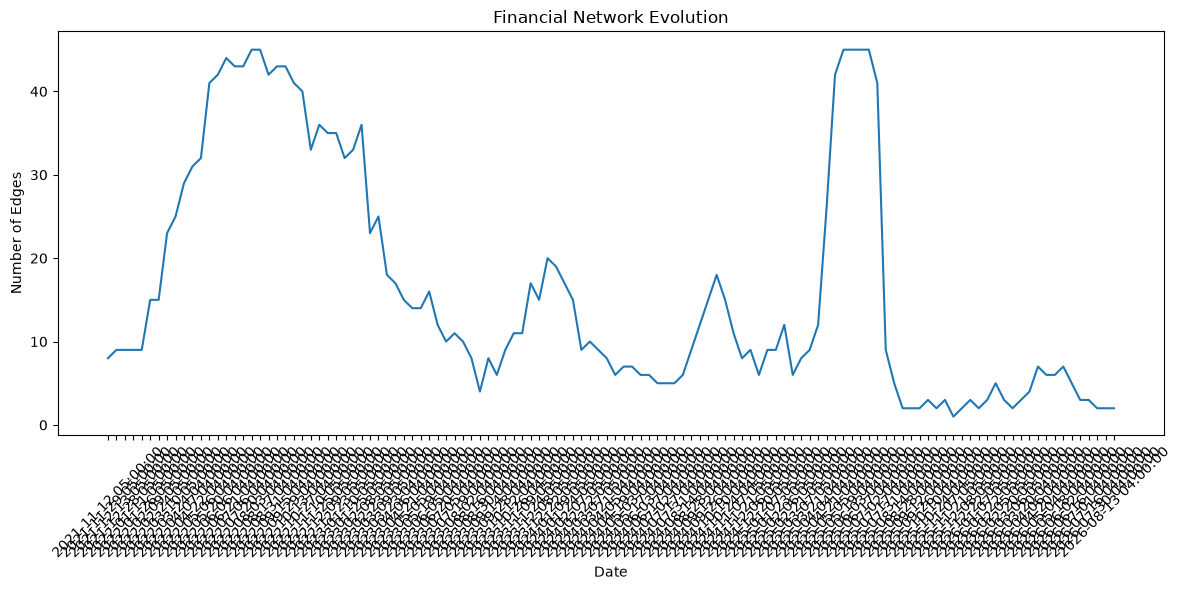

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(
    evolution_df["date"],
    evolution_df["edges"]
)

plt.xlabel("Date")
plt.ylabel("Number of Edges")
plt.title("Financial Network Evolution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

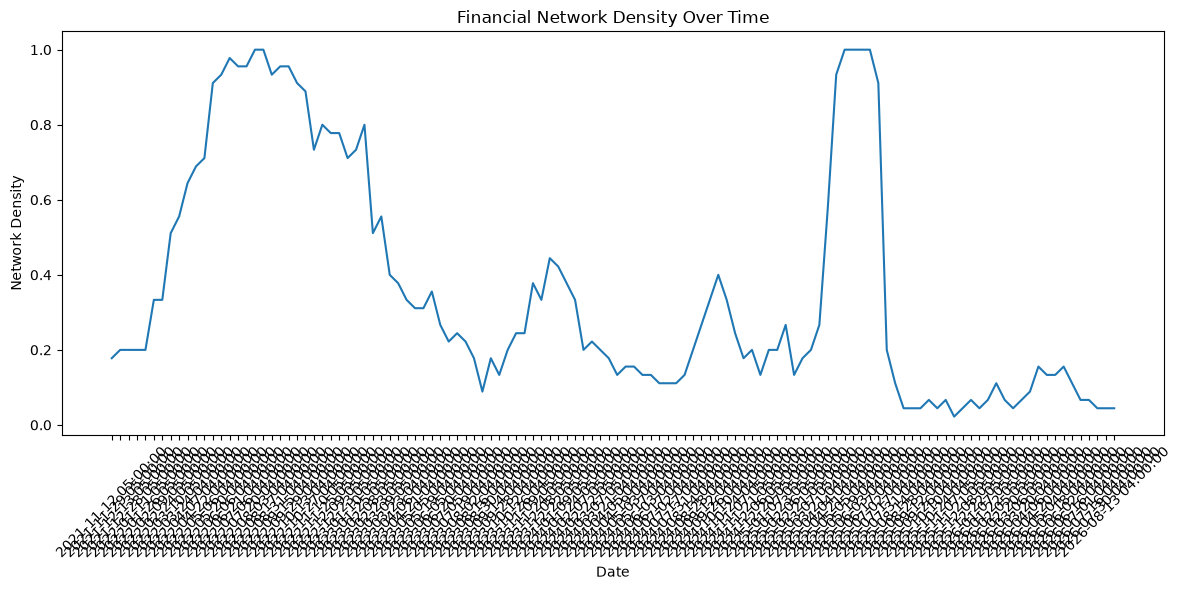

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    evolution_df["date"],
    evolution_df["density"]
)

plt.xlabel("Date")
plt.ylabel("Network Density")

plt.title(
    "Financial Network Density Over Time"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

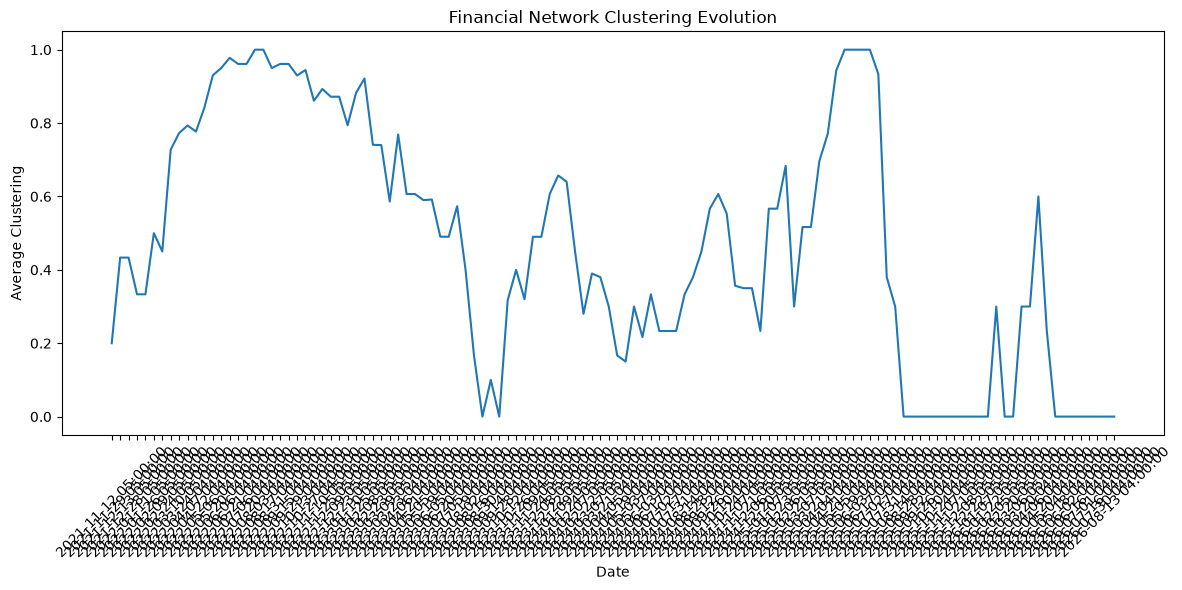

In [37]:
plt.figure(figsize=(12, 6))

plt.plot(
    evolution_df["date"],
    evolution_df["average_clustering"]
)

plt.xlabel("Date")
plt.ylabel("Average Clustering")

plt.title(
    "Financial Network Clustering Evolution"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [44]:
def calculate_node_metrics(graph):

    # Degree centrality
    degree = nx.degree_centrality(graph)

    # Betweenness centrality
    betweenness = nx.betweenness_centrality(
        graph,
        weight="distance"
    )

    # Closeness centrality
    closeness = nx.closeness_centrality(
        graph,
        distance="distance"
    )

    # Eigenvector centrality
    # Use a robust fallback for disconnected/problematic graphs
    try:
        eigenvector = nx.eigenvector_centrality(
            graph,
            max_iter=5000,
            tol=1e-06,
            weight="weight"
        )

    except nx.PowerIterationFailedConvergence:

        print(
            "Warning: Eigenvector centrality failed. "
            "Using degree centrality as fallback."
        )

        eigenvector = degree

    # Combine metrics
    metrics = {}

    for node in graph.nodes():

        metrics[node] = {
            "degree_centrality": degree.get(node, 0),
            "betweenness_centrality": betweenness.get(node, 0),
            "closeness_centrality": closeness.get(node, 0),
            "eigenvector_centrality": eigenvector.get(node, 0)
        }

    return metrics

In [45]:
print("Returns shape:", returns_df.shape)
print("Date range:", returns_df.index.min(), "to", returns_df.index.max())
print("Companies:", returns_df.shape[1])

Returns shape: (1254, 10)
Date range: 2021-08-20 04:00:00 to 2026-08-19 04:00:00
Companies: 10


In [46]:
returns_df.index = pd.to_datetime(returns_df.index)
returns_df = returns_df.sort_index()

In [47]:
import numpy as np
import networkx as nx

WINDOW_SIZE = 60
STEP_SIZE = 20
CORRELATION_THRESHOLD = 0.5

graph_snapshots = []

for start in range(
    0,
    len(returns_df) - WINDOW_SIZE + 1,
    STEP_SIZE
):

    end = start + WINDOW_SIZE

    window = returns_df.iloc[start:end]

    # Correlation matrix for this time window
    corr_matrix = window.corr()

    # Create graph
    graph = nx.Graph()

    # Add companies
    for company in corr_matrix.columns:
        graph.add_node(company)

    # Add correlation edges
    for i in range(len(corr_matrix.columns)):

        for j in range(i + 1, len(corr_matrix.columns)):

            company_a = corr_matrix.columns[i]
            company_b = corr_matrix.columns[j]

            correlation = corr_matrix.iloc[i, j]

            if pd.notna(correlation) and abs(correlation) >= CORRELATION_THRESHOLD:

                # Convert correlation into a distance
                distance = 1 - abs(correlation)

                graph.add_edge(
                    company_a,
                    company_b,
                    correlation=correlation,
                    weight=abs(correlation),
                    distance=distance
                )

    snapshot_date = window.index[-1]

    graph_snapshots.append({
        "date": snapshot_date,
        "graph": graph,
        "correlation_matrix": corr_matrix
    })

print("Number of graph snapshots:", len(graph_snapshots))

Number of graph snapshots: 60


In [48]:
for snapshot in graph_snapshots[:5]:

    graph = snapshot["graph"]

    print(
        snapshot["date"],
        "| Nodes:", graph.number_of_nodes(),
        "| Edges:", graph.number_of_edges()
    )

2021-11-12 05:00:00 | Nodes: 10 | Edges: 8
2021-12-13 05:00:00 | Nodes: 10 | Edges: 9
2022-01-11 05:00:00 | Nodes: 10 | Edges: 9
2022-02-09 05:00:00 | Nodes: 10 | Edges: 15
2022-03-10 05:00:00 | Nodes: 10 | Edges: 25


In [49]:
graph = graph_snapshots[0]["graph"]

print("Weight sample:")

for u, v, data in list(graph.edges(data=True))[:10]:
    print(
        u,
        "<->",
        v,
        "correlation =", data["correlation"],
        "weight =", data["weight"],
        "distance =", data["distance"]
    )

Weight sample:
AAPL <-> AMZN correlation = 0.6329254507086506 weight = 0.6329254507086506 distance = 0.3670745492913494
AAPL <-> GOOGL correlation = 0.5385105969015308 weight = 0.5385105969015308 distance = 0.4614894030984692
AAPL <-> MSFT correlation = 0.5484383686713946 weight = 0.5484383686713946 distance = 0.4515616313286054
AMZN <-> GOOGL correlation = 0.581515517129609 weight = 0.581515517129609 distance = 0.418484482870391
AMZN <-> NVDA correlation = 0.5028105854727751 weight = 0.5028105854727751 distance = 0.49718941452722487
GOOGL <-> MSFT correlation = 0.8197890400881239 weight = 0.8197890400881239 distance = 0.18021095991187608
MA <-> V correlation = 0.8973223359179596 weight = 0.8973223359179596 distance = 0.10267766408204038
MSFT <-> NVDA correlation = 0.5011007949152013 weight = 0.5011007949152013 distance = 0.4988992050847987


In [50]:
test_graph = graph_snapshots[0]["graph"]

test_metrics = calculate_node_metrics(test_graph)

print("Metrics calculated successfully!")
print("Number of companies:", len(test_metrics))

first_company = list(test_metrics.keys())[0]

print(
    first_company,
    test_metrics[first_company]
)

Metrics calculated successfully!
Number of companies: 10
AAPL {'degree_centrality': 0.3333333333333333, 'betweenness_centrality': 0.0, 'closeness_centrality': np.float64(0.8290367670462191), 'eigenvector_centrality': np.float64(0.4790957321467374)}


In [51]:
for snapshot in graph_snapshots[:1]:

    graph = snapshot["graph"]

    print("Nodes:", graph.number_of_nodes())
    print("Edges:", graph.number_of_edges())

    weights = [
        data.get("weight")
        for _, _, data in graph.edges(data=True)
    ]

    print("Weight sample:", weights[:10])

Nodes: 10
Edges: 8
Weight sample: [np.float64(0.6329254507086506), np.float64(0.5385105969015308), np.float64(0.5484383686713946), np.float64(0.581515517129609), np.float64(0.5028105854727751), np.float64(0.8197890400881239), np.float64(0.8973223359179596), np.float64(0.5011007949152013)]


In [52]:
weight="distance"

In [53]:
for snapshot in graph_snapshots[:1]:

    graph = snapshot["graph"]

    distances = [
        data.get("distance")
        for _, _, data in graph.edges(data=True)
    ]

    print("Distance sample:", distances[:10])

Distance sample: [np.float64(0.3670745492913494), np.float64(0.4614894030984692), np.float64(0.4515616313286054), np.float64(0.418484482870391), np.float64(0.49718941452722487), np.float64(0.18021095991187608), np.float64(0.10267766408204038), np.float64(0.4988992050847987)]


In [54]:
distance = 1 - abs(correlation)

In [55]:
all_metrics = []

for snapshot in graph_snapshots:

    date = snapshot["date"]
    graph = snapshot["graph"]

    metrics = calculate_node_metrics(graph)

    for node, values in metrics.items():

        values["date"] = date
        values["company"] = node

        all_metrics.append(values)

node_metrics_df = pd.DataFrame(all_metrics)

print("Node metrics shape:", node_metrics_df.shape)

display(node_metrics_df.head())

Node metrics shape: (600, 6)


,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality,date,company
0,0.333333,0.000000,0.829037,4.790957e-01,2021-11-12 05:00:00,AAPL
1,0.333333,0.027778,0.944901,4.333795e-01,2021-11-12 05:00:00,AMZN
2,0.333333,0.027778,1.022125,5.272720e-01,2021-11-12 05:00:00,GOOGL
3,0.000000,0.000000,0.000000,4.298179e-14,2021-11-12 05:00:00,JPM
4,0.111111,0.000000,1.082135,9.495506e-06,2021-11-12 05:00:00,MA


In [56]:
node_evolution = []

for snapshot in temporal_graphs:

    date = snapshot["date"]
    graph = snapshot["graph"]

    metrics = calculate_node_metrics(graph)

    metrics["date"] = date

    node_evolution.append(metrics)

In [58]:
type(node_evolution)

list

In [59]:
type(node_evolution[0])

dict

In [60]:
node_evolution_df = pd.DataFrame(node_evolution)

In [61]:
node_evolution_df.head()

,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V,date
0,"{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.2222222222222222, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...",2021-11-12 05:00:00
1,"{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.4444444444444444, 'bet...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.4444444444444444, 'bet...","{'degree_centrality': 0.2222222222222222, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...",2021-11-29 05:00:00
2,"{'degree_centrality': 0.2222222222222222, 'bet...","{'degree_centrality': 0.4444444444444444, 'bet...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.4444444444444444, 'bet...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...",2021-12-13 05:00:00
3,"{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.4444444444444444, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...",2021-12-28 05:00:00
4,"{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.3333333333333333, 'bet...","{'degree_centrality': 0.4444444444444444, 'bet...","{'degree_centrality': 0.0, 'betweenness_centra...","{'degree_centrality': 0.1111111111111111, 'bet...",2022-01-11 05:00:00


In [62]:
node_evolution_df.shape

(120, 11)

In [64]:
graph_snapshots[0]

{'date': Timestamp('2021-11-12 05:00:00'),
 'graph': <networkx.classes.graph.Graph at 0x26c849a35d0>,
 'correlation_matrix': ticker      AAPL      AMZN     GOOGL       JPM        MA      META      MSFT  \
 ticker                                                                         
 AAPL    1.000000  0.632925  0.538511  0.352566  0.277357  0.438259  0.548438   
 AMZN    0.632925  1.000000  0.581516  0.139288  0.264333  0.415781  0.445821   
 GOOGL   0.538511  0.581516  1.000000  0.128494  0.109118  0.449832  0.819789   
 JPM     0.352566  0.139288  0.128494  1.000000  0.398752  0.067240  0.057746   
 MA      0.277357  0.264333  0.109118  0.398752  1.000000  0.315846  0.076363   
 META    0.438259  0.415781  0.449832  0.067240  0.315846  1.000000  0.392624   
 MSFT    0.548438  0.445821  0.819789  0.057746  0.076363  0.392624  1.000000   
 NVDA    0.377291  0.502811  0.454892  0.130249  0.202463  0.303239  0.501101   
 TSLA    0.125931 -0.042972 -0.011247  0.113390  0.167872  0.21705

In [65]:
graph_snapshots[0].keys()

dict_keys(['date', 'graph', 'correlation_matrix'])

In [66]:
graph = snapshot["graph"]

In [67]:
node_evolution = []

for snapshot_id, snapshot in enumerate(graph_snapshots):

    graph = snapshot["graph"]

    # Calculate centrality for this snapshot
    centrality = nx.degree_centrality(graph)

    for node in graph.nodes():

        node_evolution.append({
            "snapshot": snapshot_id,
            "ticker": node,
            "degree": graph.degree(node),
            "centrality": centrality[node]
        })

node_evolution_df = pd.DataFrame(node_evolution)

In [68]:
node_evolution_df.head()

,snapshot,ticker,degree,centrality
0,0,AAPL,3,0.333333
1,0,AMZN,3,0.333333
2,0,GOOGL,3,0.333333
3,0,JPM,0,0.000000
4,0,MA,1,0.111111


In [69]:
node_evolution_df["snapshot"].value_counts().sort_index()

snapshot
0     10
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
11    10
12    10
13    10
14    10
15    10
16    10
17    10
18    10
19    10
20    10
21    10
22    10
23    10
24    10
25    10
26    10
27    10
28    10
29    10
30    10
31    10
32    10
33    10
34    10
35    10
36    10
37    10
38    10
39    10
40    10
41    10
42    10
43    10
44    10
45    10
46    10
47    10
48    10
49    10
50    10
51    10
52    10
53    10
54    10
55    10
56    10
57    10
58    10
59    10
Name: count, dtype: int64

In [70]:
node_evolution_df.groupby("snapshot")["degree"].mean()

snapshot
0     1.6
1     1.8
2     1.8
3     3.0
4     5.0
5     6.2
6     8.2
7     8.8
8     8.6
9     9.0
10    8.6
11    8.2
12    6.6
13    7.0
14    6.4
15    7.2
16    5.0
17    3.4
18    2.8
19    3.2
20    2.0
21    2.0
22    0.8
23    1.2
24    2.2
25    3.4
26    4.0
27    3.4
28    1.8
29    1.8
30    1.2
31    1.4
32    1.2
33    1.0
34    1.2
35    2.4
36    3.6
37    2.2
38    1.8
39    1.8
40    2.4
41    1.6
42    2.4
43    8.4
44    9.0
45    9.0
46    1.8
47    0.4
48    0.4
49    0.4
50    0.2
51    0.6
52    0.6
53    0.6
54    0.6
55    1.4
56    1.2
57    1.0
58    0.6
59    0.4
Name: degree, dtype: float64

In [73]:
node_evolution = []

for snapshot_id, snapshot in enumerate(graph_snapshots):

    graph = snapshot["graph"]

    # Calculate degree centrality for this graph
    centrality = nx.degree_centrality(graph)

    for node in graph.nodes():

        node_evolution.append({
            "snapshot": snapshot_id,
            "ticker": node,
            "degree": graph.degree(node),
            "centrality": centrality[node]
        })

node_evolution_df = pd.DataFrame(node_evolution)

In [74]:
node_evolution_df = pd.DataFrame(node_evolution)

In [75]:
node_evolution_df.head(10)

,snapshot,ticker,degree,centrality
0,0,AAPL,3,0.333333
1,0,AMZN,3,0.333333
2,0,GOOGL,3,0.333333
3,0,JPM,0,0.000000
4,0,MA,1,0.111111
5,0,META,0,0.000000
6,0,MSFT,3,0.333333
7,0,NVDA,2,0.222222
8,0,TSLA,0,0.000000
9,0,V,1,0.111111


In [76]:
node_evolution_df.columns

Index(['snapshot', 'ticker', 'degree', 'centrality'], dtype='str')

In [77]:
node_evolution_df["snapshot"].nunique()

60

In [80]:
def calculate_node_metrics(graph):

    metrics = {}

    # Degree
    degree = dict(graph.degree())

    # Weighted degree / strength
    strength = dict(graph.degree(weight="weight"))

    # Betweenness
    betweenness = nx.betweenness_centrality(
        graph,
        weight="distance"
    )

    # Closeness
    closeness = nx.closeness_centrality(
        graph,
        distance="distance"
    )

    # Eigenvector centrality
    try:
        eigenvector = nx.eigenvector_centrality(
            graph,
            max_iter=5000,
            tol=1e-06,
            weight="weight"
        )

    except nx.PowerIterationFailedConvergence:

        print("Warning: Eigenvector centrality failed to converge.")
        print("Using zeros for eigenvector centrality.")

        eigenvector = {
            node: 0.0
            for node in graph.nodes()
        }

    for node in graph.nodes():

        metrics[node] = {
            "degree": degree[node],
            "strength": strength[node],
            "betweenness": betweenness[node],
            "closeness": closeness[node],
            "eigenvector": eigenvector[node]
        }

    return metrics

In [81]:
for snapshot in graph_snapshots:

    date = snapshot["date"]
    graph = snapshot["graph"]

    metrics = calculate_node_metrics(graph)

    metrics["date"] = date

In [82]:
node_evolution = []

for snapshot in graph_snapshots:

    date = snapshot["date"]
    graph = snapshot["graph"]

    metrics = calculate_node_metrics(graph)

    for ticker, values in metrics.items():

        node_evolution.append({
            "date": date,
            "ticker": ticker,
            "degree": values["degree"],
            "strength": values["strength"],
            "betweenness": values["betweenness"],
            "closeness": values["closeness"],
            "eigenvector": values["eigenvector"]
        })

node_evolution_df = pd.DataFrame(node_evolution)

In [83]:
node_evolution_df.head()

,date,ticker,degree,strength,betweenness,closeness,eigenvector
0,2021-11-12 05:00:00,AAPL,3,1.719874,0.000000,0.829037,4.790957e-01
1,2021-11-12 05:00:00,AMZN,3,1.717252,0.027778,0.944901,4.333795e-01
2,2021-11-12 05:00:00,GOOGL,3,1.939815,0.027778,1.022125,5.272720e-01
3,2021-11-12 05:00:00,JPM,0,0.000000,0.000000,0.000000,4.298179e-14
4,2021-11-12 05:00:00,MA,1,0.897322,0.000000,1.082135,9.495506e-06


In [84]:
def calculate_node_metrics(graph):

    metrics = {}

    degree = dict(graph.degree())

    strength = dict(graph.degree(weight="weight"))

    betweenness = nx.betweenness_centrality(
        graph,
        weight="distance"
    )

    closeness = nx.closeness_centrality(
        graph,
        distance="distance"
    )

    try:
        eigenvector = nx.eigenvector_centrality(
            graph,
            max_iter=5000,
            tol=1e-06,
            weight="weight"
        )

    except nx.PowerIterationFailedConvergence:
        print("Eigenvector centrality failed — using 0.")
        eigenvector = {node: 0.0 for node in graph.nodes()}

    for node in graph.nodes():

        metrics[node] = {
            "degree": degree[node],
            "strength": strength[node],
            "betweenness": betweenness[node],
            "closeness": closeness[node],
            "eigenvector": eigenvector[node]
        }

    return metrics

In [85]:
node_evolution = []

for snapshot in graph_snapshots:

    date = snapshot["date"]
    graph = snapshot["graph"]

    metrics = calculate_node_metrics(graph)

    for ticker, values in metrics.items():

        node_evolution.append({
            "date": date,
            "ticker": ticker,
            "degree": values["degree"],
            "strength": values["strength"],
            "betweenness": values["betweenness"],
            "closeness": values["closeness"],
            "eigenvector": values["eigenvector"]
        })

node_evolution_df = pd.DataFrame(node_evolution)

In [86]:
node_evolution_df.head()

,date,ticker,degree,strength,betweenness,closeness,eigenvector
0,2021-11-12 05:00:00,AAPL,3,1.719874,0.000000,0.829037,4.790957e-01
1,2021-11-12 05:00:00,AMZN,3,1.717252,0.027778,0.944901,4.333795e-01
2,2021-11-12 05:00:00,GOOGL,3,1.939815,0.027778,1.022125,5.272720e-01
3,2021-11-12 05:00:00,JPM,0,0.000000,0.000000,0.000000,4.298179e-14
4,2021-11-12 05:00:00,MA,1,0.897322,0.000000,1.082135,9.495506e-06


In [88]:
node_evolution_df = pd.DataFrame(node_evolution)

In [89]:
node_evolution_df.head()

,date,ticker,degree,strength,betweenness,closeness,eigenvector
0,2021-11-12 05:00:00,AAPL,3,1.719874,0.000000,0.829037,4.790957e-01
1,2021-11-12 05:00:00,AMZN,3,1.717252,0.027778,0.944901,4.333795e-01
2,2021-11-12 05:00:00,GOOGL,3,1.939815,0.027778,1.022125,5.272720e-01
3,2021-11-12 05:00:00,JPM,0,0.000000,0.000000,0.000000,4.298179e-14
4,2021-11-12 05:00:00,MA,1,0.897322,0.000000,1.082135,9.495506e-06


In [90]:
node_evolution_df.shape

(600, 7)

In [92]:
node_evolution_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         600 non-null    datetime64[us]
 1   ticker       600 non-null    str           
 2   degree       600 non-null    int64         
 3   strength     600 non-null    float64       
 4   betweenness  600 non-null    float64       
 5   closeness    600 non-null    float64       
 6   eigenvector  600 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 32.9 KB


In [93]:
node_evolution_df.groupby("date")["ticker"].count()

date
2021-11-12 05:00:00    10
2021-12-13 05:00:00    10
2022-01-11 05:00:00    10
2022-02-09 05:00:00    10
2022-03-10 05:00:00    10
2022-04-07 04:00:00    10
2022-05-06 04:00:00    10
2022-06-06 04:00:00    10
2022-07-06 04:00:00    10
2022-08-03 04:00:00    10
2022-08-31 04:00:00    10
2022-09-29 04:00:00    10
2022-10-27 04:00:00    10
2022-11-25 05:00:00    10
2022-12-23 05:00:00    10
2023-01-25 05:00:00    10
2023-02-23 05:00:00    10
2023-03-23 04:00:00    10
2023-04-21 04:00:00    10
2023-05-19 04:00:00    10
2023-06-20 04:00:00    10
2023-07-19 04:00:00    10
2023-08-16 04:00:00    10
2023-09-14 04:00:00    10
2023-10-12 04:00:00    10
2023-11-09 05:00:00    10
2023-12-08 05:00:00    10
2024-01-09 05:00:00    10
2024-02-07 05:00:00    10
2024-03-07 05:00:00    10
2024-04-05 04:00:00    10
2024-05-03 04:00:00    10
2024-06-03 04:00:00    10
2024-07-02 04:00:00    10
2024-07-31 04:00:00    10
2024-08-28 04:00:00    10
2024-09-26 04:00:00    10
2024-10-24 04:00:00    10
2024-11

In [94]:
node_evolution_df = node_evolution_df.sort_values(
    ["ticker", "date"]
).reset_index(drop=True)

In [95]:
for metric in [
    "degree",
    "strength",
    "betweenness",
    "closeness",
    "eigenvector"
]:

    node_evolution_df[f"{metric}_change"] = (
        node_evolution_df
        .groupby("ticker")[metric]
        .diff()
    )

In [96]:
node_change_summary = (
    node_evolution_df
    .groupby("ticker")
    .agg({
        "degree_change": lambda x: x.abs().mean(),
        "strength_change": lambda x: x.abs().mean(),
        "betweenness_change": lambda x: x.abs().mean(),
        "closeness_change": lambda x: x.abs().mean(),
        "eigenvector_change": lambda x: x.abs().mean()
    })
    .reset_index()
)

In [97]:
node_change_summary.columns = [
    "ticker",
    "avg_degree_change",
    "avg_strength_change",
    "avg_betweenness_change",
    "avg_closeness_change",
    "avg_eigenvector_change"
]

In [98]:
node_change_summary.sort_values(
    "avg_betweenness_change",
    ascending=False
).head(10)

,ticker,avg_degree_change,avg_strength_change,avg_betweenness_change,avg_closeness_change,avg_eigenvector_change
6,MSFT,1.033898,0.722232,0.059793,0.395812,0.069903
0,AAPL,1.135593,0.772890,0.048964,0.455246,0.065611
1,AMZN,0.915254,0.654769,0.044727,0.368534,0.082417
4,MA,0.813559,0.566291,0.034840,0.330310,0.083614
5,META,1.152542,0.795049,0.031073,0.376209,0.094137
9,V,0.813559,0.576693,0.024482,0.327887,0.084229
7,NVDA,1.152542,0.798190,0.020716,0.460703,0.086956
8,TSLA,1.050847,0.683270,0.019774,0.394900,0.071187
2,GOOGL,0.881356,0.640656,0.016478,0.338054,0.065283
3,JPM,0.847458,0.541173,0.011299,0.341921,0.053929


In [99]:
node_change_summary["network_instability"] = (
    node_change_summary["avg_degree_change"].rank(pct=True)
    + node_change_summary["avg_strength_change"].rank(pct=True)
    + node_change_summary["avg_betweenness_change"].rank(pct=True)
    + node_change_summary["avg_closeness_change"].rank(pct=True)
    + node_change_summary["avg_eigenvector_change"].rank(pct=True)
) / 5

In [100]:
node_change_summary.sort_values(
    "network_instability",
    ascending=False
).head(10)

,ticker,avg_degree_change,avg_strength_change,avg_betweenness_change,avg_closeness_change,avg_eigenvector_change,network_instability
7,NVDA,1.152542,0.798190,0.020716,0.460703,0.086956,0.85
5,META,1.152542,0.795049,0.031073,0.376209,0.094137,0.81
0,AAPL,1.135593,0.772890,0.048964,0.455246,0.065611,0.74
6,MSFT,1.033898,0.722232,0.059793,0.395812,0.069903,0.70
1,AMZN,0.915254,0.654769,0.044727,0.368534,0.082417,0.58
8,TSLA,1.050847,0.683270,0.019774,0.394900,0.071187,0.56
4,MA,0.813559,0.566291,0.034840,0.330310,0.083614,0.39
9,V,0.813559,0.576693,0.024482,0.327887,0.084229,0.37
2,GOOGL,0.881356,0.640656,0.016478,0.338054,0.065283,0.30
3,JPM,0.847458,0.541173,0.011299,0.341921,0.053929,0.20


In [103]:
node_evolution_df.columns.tolist()

['date',
 'ticker',
 'degree',
 'strength',
 'betweenness',
 'closeness',
 'eigenvector',
 'degree_change',
 'strength_change',
 'betweenness_change',
 'closeness_change',
 'eigenvector_change']

In [105]:
node_evolution_df.groupby("ticker")

In [106]:
node_evolution_df["ticker"]

0      AAPL
1      AAPL
2      AAPL
3      AAPL
4      AAPL
       ... 
595       V
596       V
597       V
598       V
599       V
Name: ticker, Length: 600, dtype: str

In [107]:
node_evolution_df.sort_values(["ticker", "date"])

,date,ticker,degree,strength,betweenness,closeness,eigenvector,degree_change,strength_change,betweenness_change,closeness_change,eigenvector_change
0,2021-11-12 05:00:00,AAPL,3,1.719874,0.000000,0.829037,0.479096,NaN,NaN,NaN,NaN,NaN
1,2021-12-13 05:00:00,AAPL,2,1.163385,0.000000,0.819259,0.286102,-1.0,-0.556490,0.000000,-0.009777,-1.929936e-01
2,2022-01-11 05:00:00,AAPL,3,1.723417,0.000000,0.949838,0.400180,1.0,0.560033,0.000000,0.130578,1.140780e-01
3,2022-02-09 05:00:00,AAPL,4,2.560198,0.000000,1.449449,0.413622,1.0,0.836780,0.000000,0.499611,1.344219e-02
4,2022-03-10 05:00:00,AAPL,6,4.301159,0.055556,2.437032,0.383564,2.0,1.740961,0.055556,0.987583,-3.005811e-02
...,...,...,...,...,...,...,...,...,...,...,...,...
595,2026-04-06 04:00:00,V,2,1.410120,0.000000,0.753449,0.605778,0.0,0.025037,0.000000,0.030678,-1.392514e-03
596,2026-05-04 04:00:00,V,1,0.837484,0.000000,0.683694,0.000024,-1.0,-0.572636,0.000000,-0.069755,-6.057540e-01
597,2026-06-02 04:00:00,V,1,0.813431,0.000000,0.595549,0.000060,0.0,-0.024053,0.000000,-0.088145,3.578589e-05
598,2026-07-01 04:00:00,V,1,0.811105,0.000000,0.588217,0.707106,0.0,-0.002326,0.000000,-0.007332,7.070465e-01


In [108]:
node_change_summary = (
    node_evolution_df
    .groupby("ticker")
    .agg({
        "degree_change": lambda x: x.abs().mean(),
        "strength_change": lambda x: x.abs().mean(),
        "betweenness_change": lambda x: x.abs().mean(),
        "closeness_change": lambda x: x.abs().mean(),
        "eigenvector_change": lambda x: x.abs().mean()
    })
    .reset_index()
)

In [109]:
node_change_summary.columns = [
    "ticker",
    "avg_degree_change",
    "avg_strength_change",
    "avg_betweenness_change",
    "avg_closeness_change",
    "avg_eigenvector_change"
]

In [111]:
node_change_summary["network_instability"] = (
    node_change_summary["avg_degree_change"].rank(pct=True)
    + node_change_summary["avg_strength_change"].rank(pct=True)
    + node_change_summary["avg_betweenness_change"].rank(pct=True)
    + node_change_summary["avg_closeness_change"].rank(pct=True)
    + node_change_summary["avg_eigenvector_change"].rank(pct=True)
) / 5

In [112]:
node_change_summary.sort_values(
    "network_instability",
    ascending=False
).head(10)

,ticker,avg_degree_change,avg_strength_change,avg_betweenness_change,avg_closeness_change,avg_eigenvector_change,network_instability
7,NVDA,1.152542,0.798190,0.020716,0.460703,0.086956,0.85
5,META,1.152542,0.795049,0.031073,0.376209,0.094137,0.81
0,AAPL,1.135593,0.772890,0.048964,0.455246,0.065611,0.74
6,MSFT,1.033898,0.722232,0.059793,0.395812,0.069903,0.70
1,AMZN,0.915254,0.654769,0.044727,0.368534,0.082417,0.58
8,TSLA,1.050847,0.683270,0.019774,0.394900,0.071187,0.56
4,MA,0.813559,0.566291,0.034840,0.330310,0.083614,0.39
9,V,0.813559,0.576693,0.024482,0.327887,0.084229,0.37
2,GOOGL,0.881356,0.640656,0.016478,0.338054,0.065283,0.30
3,JPM,0.847458,0.541173,0.011299,0.341921,0.053929,0.20


In [114]:
print(node_evolution_df.columns.tolist())

['date', 'ticker', 'degree', 'strength', 'betweenness', 'closeness', 'eigenvector', 'degree_change', 'strength_change', 'betweenness_change', 'closeness_change', 'eigenvector_change']


In [115]:
print(node_change_summary.columns.tolist())

['ticker', 'avg_degree_change', 'avg_strength_change', 'avg_betweenness_change', 'avg_closeness_change', 'avg_eigenvector_change', 'network_instability']


In [116]:
# Make sure the dataframe is sorted correctly
node_evolution_df = node_evolution_df.sort_values(
    ["ticker", "date"]
).reset_index(drop=True)


# Calculate temporal changes
for metric in [
    "degree",
    "strength",
    "betweenness",
    "closeness",
    "eigenvector"
]:

    node_evolution_df[f"{metric}_change"] = (
        node_evolution_df
        .groupby("ticker")[metric]
        .diff()
    )


# Calculate average absolute change for each company
node_change_summary = (
    node_evolution_df
    .groupby("ticker")
    .agg(
        avg_degree_change=("degree_change", lambda x: x.abs().mean()),
        avg_strength_change=("strength_change", lambda x: x.abs().mean()),
        avg_betweenness_change=("betweenness_change", lambda x: x.abs().mean()),
        avg_closeness_change=("closeness_change", lambda x: x.abs().mean()),
        avg_eigenvector_change=("eigenvector_change", lambda x: x.abs().mean())
    )
    .reset_index()
)


# Composite network instability score
node_change_summary["network_instability"] = (
    node_change_summary["avg_degree_change"].rank(pct=True)
    + node_change_summary["avg_strength_change"].rank(pct=True)
    + node_change_summary["avg_betweenness_change"].rank(pct=True)
    + node_change_summary["avg_closeness_change"].rank(pct=True)
    + node_change_summary["avg_eigenvector_change"].rank(pct=True)
) / 5

In [117]:
node_change_summary.head()

,ticker,avg_degree_change,avg_strength_change,avg_betweenness_change,avg_closeness_change,avg_eigenvector_change,network_instability
0,AAPL,1.135593,0.772890,0.048964,0.455246,0.065611,0.74
1,AMZN,0.915254,0.654769,0.044727,0.368534,0.082417,0.58
2,GOOGL,0.881356,0.640656,0.016478,0.338054,0.065283,0.30
3,JPM,0.847458,0.541173,0.011299,0.341921,0.053929,0.20
4,MA,0.813559,0.566291,0.034840,0.330310,0.083614,0.39


In [118]:
node_change_summary.sort_values(
    "network_instability",
    ascending=False
).head(10)

,ticker,avg_degree_change,avg_strength_change,avg_betweenness_change,avg_closeness_change,avg_eigenvector_change,network_instability
7,NVDA,1.152542,0.798190,0.020716,0.460703,0.086956,0.85
5,META,1.152542,0.795049,0.031073,0.376209,0.094137,0.81
0,AAPL,1.135593,0.772890,0.048964,0.455246,0.065611,0.74
6,MSFT,1.033898,0.722232,0.059793,0.395812,0.069903,0.70
1,AMZN,0.915254,0.654769,0.044727,0.368534,0.082417,0.58
8,TSLA,1.050847,0.683270,0.019774,0.394900,0.071187,0.56
4,MA,0.813559,0.566291,0.034840,0.330310,0.083614,0.39
9,V,0.813559,0.576693,0.024482,0.327887,0.084229,0.37
2,GOOGL,0.881356,0.640656,0.016478,0.338054,0.065283,0.30
3,JPM,0.847458,0.541173,0.011299,0.341921,0.053929,0.20


In [119]:
company = "AAPL"

In [121]:
print("node_evolution_df columns:")
print(node_evolution_df.columns.tolist())

print("\nnode_change_summary exists:")
print("node_change_summary" in globals())

if "node_change_summary" in globals():
    print("\nnode_change_summary columns:")
    print(node_change_summary.columns.tolist())

node_evolution_df columns:
['date', 'ticker', 'degree', 'strength', 'betweenness', 'closeness', 'eigenvector', 'degree_change', 'strength_change', 'betweenness_change', 'closeness_change', 'eigenvector_change']

node_change_summary exists:
True

node_change_summary columns:
['ticker', 'avg_degree_change', 'avg_strength_change', 'avg_betweenness_change', 'avg_closeness_change', 'avg_eigenvector_change', 'network_instability']


In [122]:
if "company" not in node_evolution_df.columns:
    node_evolution_df["company"] = node_evolution_df["ticker"]

In [123]:
node_evolution_df.columns.tolist()

['date',
 'ticker',
 'degree',
 'strength',
 'betweenness',
 'closeness',
 'eigenvector',
 'degree_change',
 'strength_change',
 'betweenness_change',
 'closeness_change',
 'eigenvector_change',
 'company']

In [124]:
node_evolution_df["company"]

0      AAPL
1      AAPL
2      AAPL
3      AAPL
4      AAPL
       ... 
595       V
596       V
597       V
598       V
599       V
Name: company, Length: 600, dtype: str

In [125]:
print(node_evolution_df.columns.tolist())

['date', 'ticker', 'degree', 'strength', 'betweenness', 'closeness', 'eigenvector', 'degree_change', 'strength_change', 'betweenness_change', 'closeness_change', 'eigenvector_change', 'company']


In [126]:
print("node_evolution_df:", node_evolution_df.columns.tolist())

if "node_change_summary" in globals():
    print("node_change_summary:", node_change_summary.columns.tolist())

if "company_analysis" in globals():
    print("company_analysis:", company_analysis.columns.tolist())

if "community_risk" in globals():
    print("community_risk:", community_risk.columns.tolist())

node_evolution_df: ['date', 'ticker', 'degree', 'strength', 'betweenness', 'closeness', 'eigenvector', 'degree_change', 'strength_change', 'betweenness_change', 'closeness_change', 'eigenvector_change', 'company']
node_change_summary: ['ticker', 'avg_degree_change', 'avg_strength_change', 'avg_betweenness_change', 'avg_closeness_change', 'avg_eigenvector_change', 'network_instability']


In [127]:
# Ensure correct ordering
node_evolution_df = node_evolution_df.sort_values(
    ["ticker", "date"]
).reset_index(drop=True)


# Build network instability summary
node_change_summary = (
    node_evolution_df
    .groupby("ticker")
    .agg(
        avg_degree_change=("degree_change", lambda x: x.abs().mean()),
        avg_strength_change=("strength_change", lambda x: x.abs().mean()),
        avg_betweenness_change=("betweenness_change", lambda x: x.abs().mean()),
        avg_closeness_change=("closeness_change", lambda x: x.abs().mean()),
        avg_eigenvector_change=("eigenvector_change", lambda x: x.abs().mean())
    )
    .reset_index()
)


# Composite instability score
node_change_summary["network_instability"] = (
    node_change_summary["avg_degree_change"].rank(pct=True)
    + node_change_summary["avg_strength_change"].rank(pct=True)
    + node_change_summary["avg_betweenness_change"].rank(pct=True)
    + node_change_summary["avg_closeness_change"].rank(pct=True)
    + node_change_summary["avg_eigenvector_change"].rank(pct=True)
) / 5


# Rank companies
node_change_summary = node_change_summary.sort_values(
    "network_instability",
    ascending=False
).reset_index(drop=True)

node_change_summary.head(10)

,ticker,avg_degree_change,avg_strength_change,avg_betweenness_change,avg_closeness_change,avg_eigenvector_change,network_instability
0,NVDA,1.152542,0.798190,0.020716,0.460703,0.086956,0.85
1,META,1.152542,0.795049,0.031073,0.376209,0.094137,0.81
2,AAPL,1.135593,0.772890,0.048964,0.455246,0.065611,0.74
3,MSFT,1.033898,0.722232,0.059793,0.395812,0.069903,0.70
4,AMZN,0.915254,0.654769,0.044727,0.368534,0.082417,0.58
5,TSLA,1.050847,0.683270,0.019774,0.394900,0.071187,0.56
6,MA,0.813559,0.566291,0.034840,0.330310,0.083614,0.39
7,V,0.813559,0.576693,0.024482,0.327887,0.084229,0.37
8,GOOGL,0.881356,0.640656,0.016478,0.338054,0.065283,0.30
9,JPM,0.847458,0.541173,0.011299,0.341921,0.053929,0.20


In [128]:
node_change_summary.columns.tolist()

['ticker',
 'avg_degree_change',
 'avg_strength_change',
 'avg_betweenness_change',
 'avg_closeness_change',
 'avg_eigenvector_change',
 'network_instability']

In [129]:
node_change_summary.head(10)

,ticker,avg_degree_change,avg_strength_change,avg_betweenness_change,avg_closeness_change,avg_eigenvector_change,network_instability
0,NVDA,1.152542,0.798190,0.020716,0.460703,0.086956,0.85
1,META,1.152542,0.795049,0.031073,0.376209,0.094137,0.81
2,AAPL,1.135593,0.772890,0.048964,0.455246,0.065611,0.74
3,MSFT,1.033898,0.722232,0.059793,0.395812,0.069903,0.70
4,AMZN,0.915254,0.654769,0.044727,0.368534,0.082417,0.58
5,TSLA,1.050847,0.683270,0.019774,0.394900,0.071187,0.56
6,MA,0.813559,0.566291,0.034840,0.330310,0.083614,0.39
7,V,0.813559,0.576693,0.024482,0.327887,0.084229,0.37
8,GOOGL,0.881356,0.640656,0.016478,0.338054,0.065283,0.30
9,JPM,0.847458,0.541173,0.011299,0.341921,0.053929,0.20


In [130]:
node_evolution_df = node_evolution_df.drop(
    columns=["company"]
)

In [131]:
node_evolution_df.columns.tolist()

['date',
 'ticker',
 'degree',
 'strength',
 'betweenness',
 'closeness',
 'eigenvector',
 'degree_change',
 'strength_change',
 'betweenness_change',
 'closeness_change',
 'eigenvector_change']

In [132]:
company = "AAPL"

aapl_history = node_evolution_df[
    node_evolution_df["ticker"] == company
].copy()

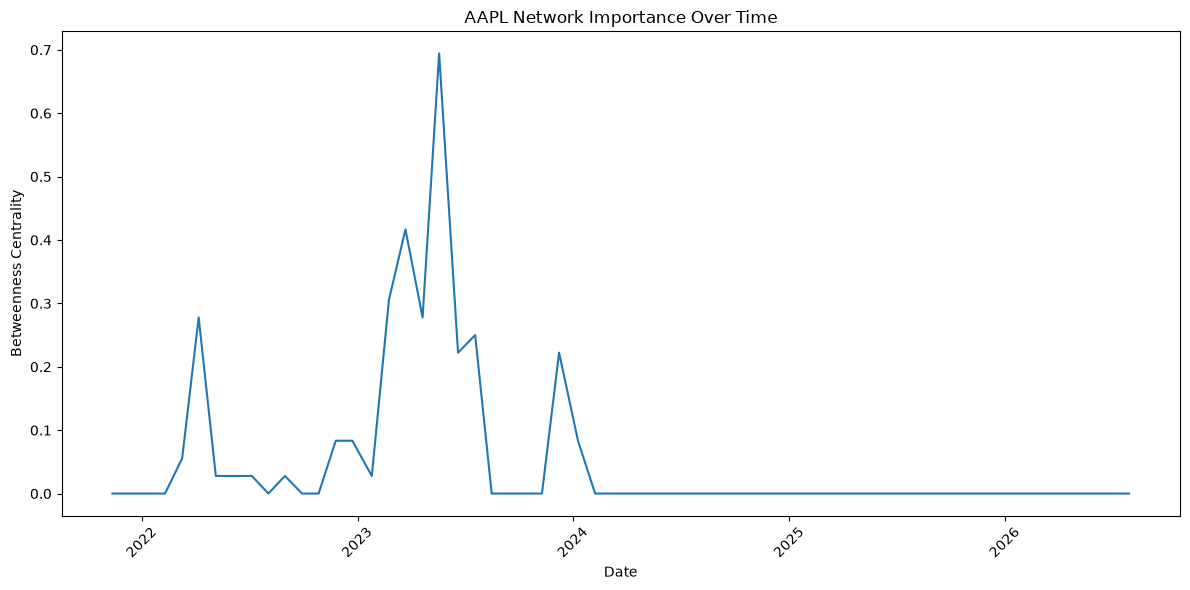

In [134]:
plt.figure(figsize=(12, 6))

plt.plot(
    aapl_history["date"],
    aapl_history["betweenness"]
)

plt.xlabel("Date")
plt.ylabel("Betweenness Centrality")

plt.title(
    f"{company} Network Importance Over Time"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [135]:
evolution_df["edge_change"] = (
    evolution_df["edges"]
    .pct_change()
)

In [136]:
evolution_df["density_change"] = (
    evolution_df["density"]
    .pct_change()
)

In [137]:
evolution_df["clustering_change"] = (
    evolution_df["average_clustering"]
    .pct_change()
)

In [138]:
evolution_df.sort_values(
    "edge_change"
).head(10)

,nodes,edges,density,average_degree,average_clustering,connected_components,date,edge_change,density_change,clustering_change
92,10,9,0.200000,1.8,0.380000,4,2025-07-17 04:00:00,-0.780488,-0.780488,-0.592857
100,10,1,0.022222,0.2,0.000000,9,2025-11-07 05:00:00,-0.666667,-0.666667,NaN
94,10,2,0.044444,0.4,0.000000,8,2025-08-14 04:00:00,-0.600000,-0.600000,-1.000000
44,10,4,0.088889,0.8,0.000000,6,2023-08-16 04:00:00,-0.500000,-0.500000,-1.000000
81,10,6,0.133333,1.2,0.300000,5,2025-02-06 05:00:00,-0.500000,-0.500000,-0.560976
93,10,5,0.111111,1.0,0.300000,6,2025-07-31 04:00:00,-0.444444,-0.444444,-0.210526
106,10,3,0.066667,0.6,0.000000,7,2026-02-05 05:00:00,-0.400000,-0.400000,-1.000000
56,10,9,0.200000,1.8,0.280000,3,2024-02-07 05:00:00,-0.400000,-0.400000,-0.377778
115,10,3,0.066667,0.6,0.000000,7,2026-06-16 04:00:00,-0.400000,-0.400000,NaN
31,10,23,0.511111,4.6,0.740714,2,2023-02-08 05:00:00,-0.361111,-0.361111,-0.196124


In [139]:
def simulate_shock(
    graph,
    shocked_company,
    initial_shock=-0.20,
    decay=0.5,
    threshold=0.05
):

    shock_values = {
        node: 0.0
        for node in graph.nodes()
    }

    if shocked_company not in graph:
        return shock_values

    shock_values[shocked_company] = initial_shock

    queue = [
        (shocked_company, initial_shock)
    ]

    visited = set()

    while queue:

        current, current_shock = queue.pop(0)

        if current in visited:
            continue

        visited.add(current)

        for neighbor in graph.neighbors(current):

            edge_data = graph[
                current
            ][neighbor]

            correlation = abs(
                edge_data["correlation"]
            )

            propagated_shock = (
                current_shock
                * correlation
                * decay
            )

            if abs(propagated_shock) >= threshold:

                shock_values[neighbor] += (
                    propagated_shock
                )

                queue.append(
                    (
                        neighbor,
                        propagated_shock
                    )
                )

    return shock_values

In [140]:
shocked_company = "AAPL"

In [141]:
snapshot = temporal_graphs[-1]

graph = snapshot["graph"]

In [142]:
shock_result = simulate_shock(
    graph,
    shocked_company,
    initial_shock=-0.20
)

In [143]:
shock_df = pd.DataFrame(
    shock_result.items(),
    columns=[
        "company",
        "shock"
    ]
)

In [144]:
shock_df = shock_df.sort_values(
    "shock"
)

In [145]:
shock_df.head(10)

,company,shock
0,AAPL,-0.2
1,AMZN,0.0
2,GOOGL,0.0
3,JPM,0.0
4,MA,0.0
5,META,0.0
6,MSFT,0.0
7,NVDA,0.0
8,TSLA,0.0
9,V,0.0


In [146]:
dynamic_shocks = []

shocked_company = "AAPL"

for snapshot in temporal_graphs:

    date = snapshot["date"]
    graph = snapshot["graph"]

    if shocked_company not in graph:
        continue

    shock_result = simulate_shock(
        graph,
        shocked_company,
        initial_shock=-0.20
    )

    total_impact = sum(
        abs(value)
        for value in shock_result.values()
    )

    affected_companies = sum(
        1
        for value in shock_result.values()
        if abs(value) > 0.01
    )

    dynamic_shocks.append({

        "date": date,

        "shocked_company":
            shocked_company,

        "total_impact":
            total_impact,

        "affected_companies":
            affected_companies
    })

In [147]:
dynamic_shock_df = pd.DataFrame(
    dynamic_shocks
)

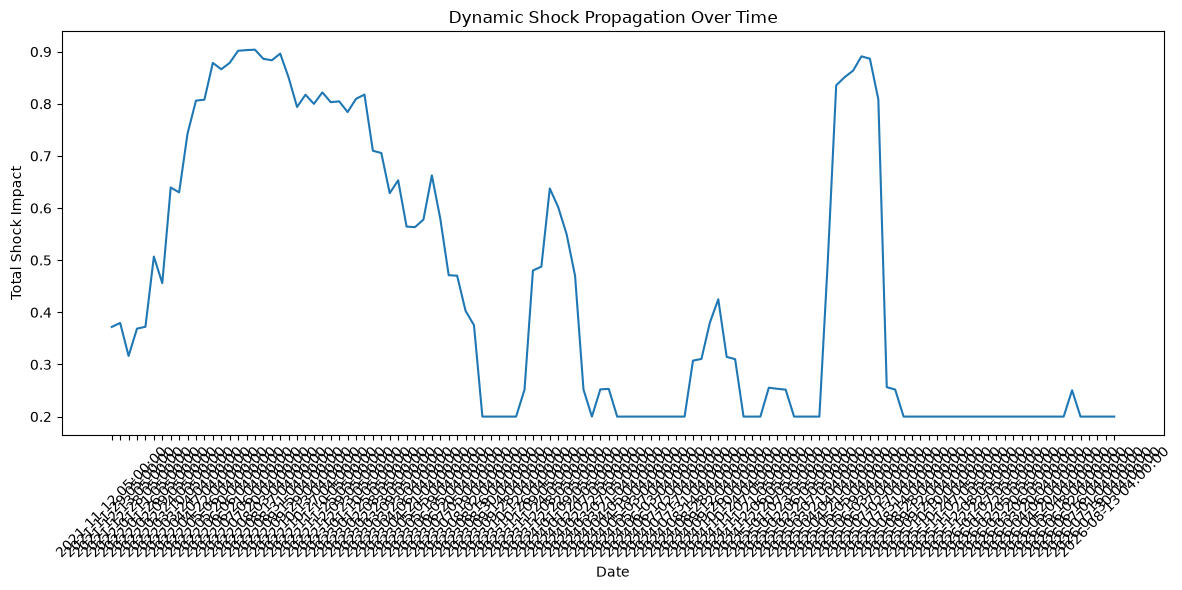

In [148]:
plt.figure(figsize=(12, 6))

plt.plot(
    dynamic_shock_df["date"],
    dynamic_shock_df["total_impact"]
)

plt.xlabel("Date")
plt.ylabel("Total Shock Impact")

plt.title(
    "Dynamic Shock Propagation Over Time"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [149]:
systemic_scores = []

In [150]:
for snapshot in temporal_graphs:

    date = snapshot["date"]
    graph = snapshot["graph"]

    if graph.number_of_nodes() == 0:
        continue

    degree = nx.degree_centrality(graph)

    betweenness = nx.betweenness_centrality(
        graph,
        weight="distance"
    )

    pagerank = nx.pagerank(
        graph,
        weight="weight"
    )

    for company in graph.nodes():

        systemic_score = (

            0.30 * degree.get(company, 0)

            + 0.30 * betweenness.get(
                company,
                0
            )

            + 0.40 * pagerank.get(
                company,
                0
            )
        )

        systemic_scores.append({

            "date": date,

            "company": company,

            "degree":
                degree.get(company, 0),

            "betweenness":
                betweenness.get(
                    company,
                    0
                ),

            "pagerank":
                pagerank.get(
                    company,
                    0
                ),

            "systemic_risk_score":
                systemic_score
        })

In [151]:
systemic_risk_df = pd.DataFrame(
    systemic_scores
)

In [152]:
top_systemic = (
    systemic_risk_df
    .sort_values(
        [
            "date",
            "systemic_risk_score"
        ],
        ascending=[
            True,
            False
        ]
    )
)

In [153]:
top_5_each_period = (
    top_systemic
    .groupby("date")
    .head(5)
)

In [154]:
top_5_each_period.head(20)

,date,company,degree,betweenness,pagerank,systemic_risk_score
2,2021-11-12 05:00:00,GOOGL,0.333333,0.027778,0.153270,0.169641
6,2021-11-12 05:00:00,MSFT,0.333333,0.027778,0.150440,0.168509
1,2021-11-12 05:00:00,AMZN,0.333333,0.027778,0.140320,0.164461
0,2021-11-12 05:00:00,AAPL,0.333333,0.000000,0.137777,0.155111
7,2021-11-12 05:00:00,NVDA,0.222222,0.000000,0.089335,0.102400
16,2021-11-29 05:00:00,MSFT,0.444444,0.027778,0.165680,0.207938
11,2021-11-29 05:00:00,AMZN,0.444444,0.027778,0.160079,0.205698
12,2021-11-29 05:00:00,GOOGL,0.333333,0.000000,0.138485,0.155394
10,2021-11-29 05:00:00,AAPL,0.333333,0.000000,0.122589,0.149036
17,2021-11-29 05:00:00,NVDA,0.222222,0.000000,0.084308,0.100390


In [155]:
risk_matrix = systemic_risk_df.pivot(
    index="company",
    columns="date",
    values="systemic_risk_score"
)

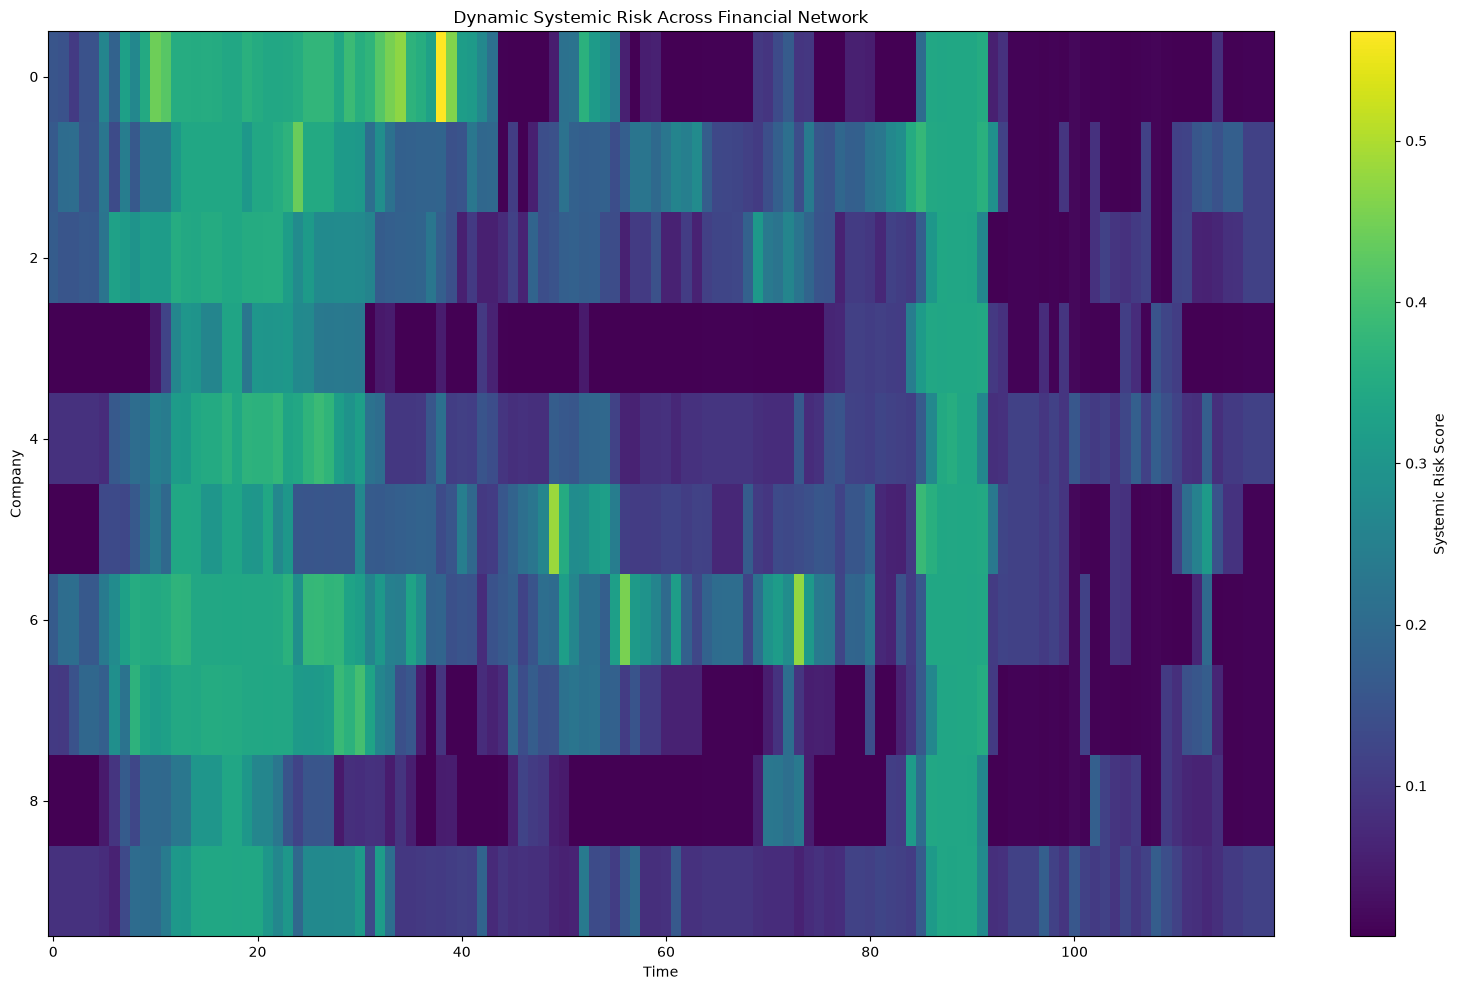

In [156]:
plt.figure(figsize=(16, 10))

plt.imshow(
    risk_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Systemic Risk Score"
)

plt.xlabel("Time")
plt.ylabel("Company")

plt.title(
    "Dynamic Systemic Risk Across Financial Network"
)

plt.tight_layout()

plt.show()

In [157]:
results_path = Path(
    "../data/results"
)

results_path.mkdir(
    parents=True,
    exist_ok=True
)

In [159]:
evolution_df.to_csv(
    results_path /
    "network_evolution.csv",
    index=False
)

In [160]:
node_evolution_df.to_csv(
    results_path /
    "node_network_evolution.csv",
    index=False
)

In [161]:
dynamic_shock_df.to_csv(
    results_path /
    "dynamic_shock_propagation.csv",
    index=False
)

In [163]:
systemic_risk_df.to_csv(
    results_path /
    "dynamic_systemic_risk.csv",
    index=False
)